In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from itertools import product
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling — clean and professional
plt.rcParams['figure.dpi']    = 120
plt.rcParams['font.family']   = 'sans-serif'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Most influential parameters in SLA printing

PARAMETERS = {
    'layer_height_um': {
        'values': [25, 50, 100],        # microns — thin to thick layers
        'unit':   'µm',
        'label':  'Layer Height'
    },
    'exposure_time_ms': {
        'values': [80, 120, 160],       # milliseconds — under to over exposure
        'unit':   'ms',
        'label':  'Exposure Time'
    },
    'support_density_pct': {
        'values': [20, 50, 80],         # percent — sparse to dense supports
        'unit':   '%',
        'label':  'Support Density'
    }
}

# Output metrics we care about
METRICS = [
    'dimensional_accuracy_um',   # how close to CAD model (lower = better)
    'surface_roughness_ra',      # surface finish Ra value in microns (lower = better)
    'layer_adhesion_score',      # bond strength between layers, 0-100 (higher = better)
    'print_time_min',            # total print time in minutes (lower = better)
    'delamination_risk_pct',     # probability of layer separation (lower = better)
]

print("Print Parameters:")
print("-" * 50)
for key, val in PARAMETERS.items():
    print(f"  {val['label']:<22} → {val['values']} {val['unit']}")

print()
print("Output Metrics Being Evaluated:")
print("-" * 50)
for m in METRICS:
    print(f"  {m}")

Print Parameters:
--------------------------------------------------
  Layer Height           → [25, 50, 100] µm
  Exposure Time          → [80, 120, 160] ms
  Support Density        → [20, 50, 80] %

Output Metrics Being Evaluated:
--------------------------------------------------
  dimensional_accuracy_um
  surface_roughness_ra
  layer_adhesion_score
  print_time_min
  delamination_risk_pct


In [3]:
# Full factorial DOE
# 3 parameters x 3 levels each = 27 unique experimental runs

param_names  = list(PARAMETERS.keys())
param_values = [PARAMETERS[p]['values'] for p in param_names]

combinations = list(product(*param_values))

doe_df = pd.DataFrame(combinations, columns=param_names)
doe_df.index = [f'RUN-{i+1:02d}' for i in range(len(doe_df))]

print(f"Full Factorial DOE Matrix")
print(f"Parameters : {len(param_names)}")
print(f"Levels each: 3")
print(f"Total runs : {len(doe_df)}")
print()
print(doe_df.to_string())

Full Factorial DOE Matrix
Parameters : 3
Levels each: 3
Total runs : 27

        layer_height_um  exposure_time_ms  support_density_pct
RUN-01               25                80                   20
RUN-02               25                80                   50
RUN-03               25                80                   80
RUN-04               25               120                   20
RUN-05               25               120                   50
RUN-06               25               120                   80
RUN-07               25               160                   20
RUN-08               25               160                   50
RUN-09               25               160                   80
RUN-10               50                80                   20
RUN-11               50                80                   50
RUN-12               50                80                   80
RUN-13               50               120                   20
RUN-14               50               120    

In [4]:
# Each metric is derived from known SLA physics relationships

np.random.seed(42)

def compute_metrics(row):
    lh  = row['layer_height_um']       # layer height in microns
    et  = row['exposure_time_ms']      # exposure time in ms
    sd  = row['support_density_pct']   # support density in %

    #       Dimensional Accuracy
    # Thicker layers = less accuracy, overexposure = bloating/inaccuracy
    # Best accuracy at thin layers + moderate exposure
    dim_acc = (
        0.45 * lh                          # thicker layers hurt accuracy
        + 0.30 * abs(et - 120)             # deviation from optimal exposure
        - 0.10 * sd                        # denser supports help hold geometry
        + np.random.normal(0, 1.5)         # experimental noise
    )
    dim_acc = np.clip(dim_acc, 2, 60)

    #     Surface Roughness (Ra)
    # Thicker layers = rougher staircase effect on curved surfaces
    # Low exposure = incomplete cure = rough surface
    surface_ra = (
        0.055 * lh                         # layer staircase effect
        - 0.012 * et                       # more exposure = smoother cure
        + 0.018 * sd                       # more supports = contact marks
        + np.random.normal(0, 0.3)
    )
    surface_ra = np.clip(surface_ra, 0.5, 8.0)

    #     Layer Adhesion Score (0-100)
    # Longer exposure = better inter-layer bonding
    # Very thick layers with low exposure = poor adhesion
    adhesion = (
        100
        - 0.20 * lh                        # thick layers reduce bonding area
        + 0.18 * et                        # more exposure improves cure depth
        - 0.05 * abs(sd - 50)              # extreme support density hurts
        + np.random.normal(0, 2.0)
    )
    adhesion = np.clip(adhesion, 40, 100)

    #     Print Time
    # Thinner layers = more layers needed = longer print
    # More supports = more geometry to cure per layer
    base_layers  = 185000 / lh             # build height 185mm / layer height
    time_per_layer = (et / 1000) + 0.8    # exposure + movement overhead (sec)
    support_overhead = 1 + (sd / 200)     # support adds up to 50% overhead
    print_time = (base_layers * time_per_layer * support_overhead) / 60
    print_time += np.random.normal(0, 1.5)
    print_time = np.clip(print_time, 5, 300)

    #     Delamination Risk
    # High layer height + low exposure = highest delamination risk
    # Dense supports reduce risk by stabilizing the part during peel
    delam_risk = (
        0.35 * lh                          # thick layers peel more aggressively
        - 0.40 * et                        # more exposure = better bonding
        - 0.12 * sd                        # supports reduce peel stress
        + 25
        + np.random.normal(0, 2.0)
    )
    delam_risk = np.clip(delam_risk, 0, 95)

    return pd.Series({
        'dimensional_accuracy_um': round(dim_acc, 2),
        'surface_roughness_ra':    round(surface_ra, 2),
        'layer_adhesion_score':    round(adhesion, 2),
        'print_time_min':          round(print_time, 1),
        'delamination_risk_pct':   round(delam_risk, 2)
    })


results_df = doe_df.copy()
metrics     = results_df.apply(compute_metrics, axis=1)
results_df  = pd.concat([results_df, metrics], axis=1)

print("DOE Results — All 27 Experimental Runs")
print("-" * 95)
print(results_df.to_string())
print()
print(f"Dimensional Accuracy  — Mean: {results_df['dimensional_accuracy_um'].mean():.1f} µm  |  Range: {results_df['dimensional_accuracy_um'].min():.1f} – {results_df['dimensional_accuracy_um'].max():.1f}")
print(f"Surface Roughness Ra  — Mean: {results_df['surface_roughness_ra'].mean():.2f}    |  Range: {results_df['surface_roughness_ra'].min():.2f} – {results_df['surface_roughness_ra'].max():.2f}")
print(f"Layer Adhesion Score  — Mean: {results_df['layer_adhesion_score'].mean():.1f}    |  Range: {results_df['layer_adhesion_score'].min():.1f} – {results_df['layer_adhesion_score'].max():.1f}")
print(f"Print Time            — Mean: {results_df['print_time_min'].mean():.1f} min  |  Range: {results_df['print_time_min'].min():.1f} – {results_df['print_time_min'].max():.1f}")
print(f"Delamination Risk     — Mean: {results_df['delamination_risk_pct'].mean():.1f}%   |  Range: {results_df['delamination_risk_pct'].min():.1f} – {results_df['delamination_risk_pct'].max():.1f}")

DOE Results — All 27 Experimental Runs
-----------------------------------------------------------------------------------------------
        layer_height_um  exposure_time_ms  support_density_pct  dimensional_accuracy_um  surface_roughness_ra  layer_adhesion_score  print_time_min  delamination_risk_pct
RUN-01               25                80                   20                    22.00                  0.73                100.00           121.7                   0.00
RUN-02               25                80                   50                    17.90                  1.79                100.00           135.0                   0.00
RUN-03               25                80                   80                    14.55                  1.72                100.00           149.1                   0.00
RUN-04               25               120                   20                     8.41                  0.50                100.00           123.5                   0.00
RUN-05    

In [5]:
# Pearson correlation between each input parameter and each output metric

sensitivity = {}

for metric in METRICS:
    correlations = {}
    for param in param_names:
        r, p_value = stats.pearsonr(results_df[param], results_df[metric])
        correlations[param] = {
            'correlation': round(r, 3),
            'p_value':     round(p_value, 4),
            'significant': 'YES' if p_value < 0.05 else 'NO',
            'influence':   'STRONG' if abs(r) > 0.5 else ('MODERATE' if abs(r) > 0.25 else 'WEAK')
        }
    sensitivity[metric] = correlations

# Print the sensitivity report
param_labels = {
    'layer_height_um':      'Layer Height',
    'exposure_time_ms':     'Exposure Time',
    'support_density_pct':  'Support Density'
}

metric_labels = {
    'dimensional_accuracy_um': 'Dimensional Accuracy (µm)',
    'surface_roughness_ra':    'Surface Roughness Ra',
    'layer_adhesion_score':    'Layer Adhesion Score',
    'print_time_min':          'Print Time (min)',
    'delamination_risk_pct':   'Delamination Risk (%)'
}

print("=" * 70)
print("       PARAMETER SENSITIVITY REPORT — PEARSON CORRELATION")
print("=" * 70)

for metric, params in sensitivity.items():
    print(f"\n  {metric_labels[metric]}")
    print(f"  {'-' * 50}")
    for param, vals in params.items():
        direction = '▲ increases' if vals['correlation'] > 0 else '▼ decreases'
        print(f"  {param_labels[param]:<20} r = {vals['correlation']:>7}  |  "
              f"{vals['influence']:<10}  |  Significant: {vals['significant']}  |  "
              f"{direction} metric")

print()
print("=" * 70)
print("  Note: r = Pearson correlation coefficient")
print("  |r| > 0.5 = STRONG influence on output metric")
print("  |r| > 0.25 = MODERATE influence on output metric")
print("=" * 70)

# Build a clean summary correlation matrix for visualization in next cell
corr_matrix = pd.DataFrame(
    {metric_labels[m]: {param_labels[p]: sensitivity[m][p]['correlation']
     for p in param_names} for m in METRICS}
)

print()
print("Correlation Matrix (input parameters vs output metrics):")
print(corr_matrix.to_string())

       PARAMETER SENSITIVITY REPORT — PEARSON CORRELATION

  Dimensional Accuracy (µm)
  --------------------------------------------------
  Layer Height         r =   0.912  |  STRONG      |  Significant: YES  |  ▲ increases metric
  Exposure Time        r =   0.013  |  WEAK        |  Significant: NO  |  ▲ increases metric
  Support Density      r =  -0.169  |  WEAK        |  Significant: NO  |  ▼ decreases metric

  Surface Roughness Ra
  --------------------------------------------------
  Layer Height         r =   0.946  |  STRONG      |  Significant: YES  |  ▲ increases metric
  Exposure Time        r =  -0.202  |  WEAK        |  Significant: NO  |  ▼ decreases metric
  Support Density      r =   0.213  |  WEAK        |  Significant: NO  |  ▲ increases metric

  Layer Adhesion Score
  --------------------------------------------------
  Layer Height         r =  -0.508  |  STRONG      |  Significant: YES  |  ▼ decreases metric
  Exposure Time        r =   0.421  |  MODERATE    |

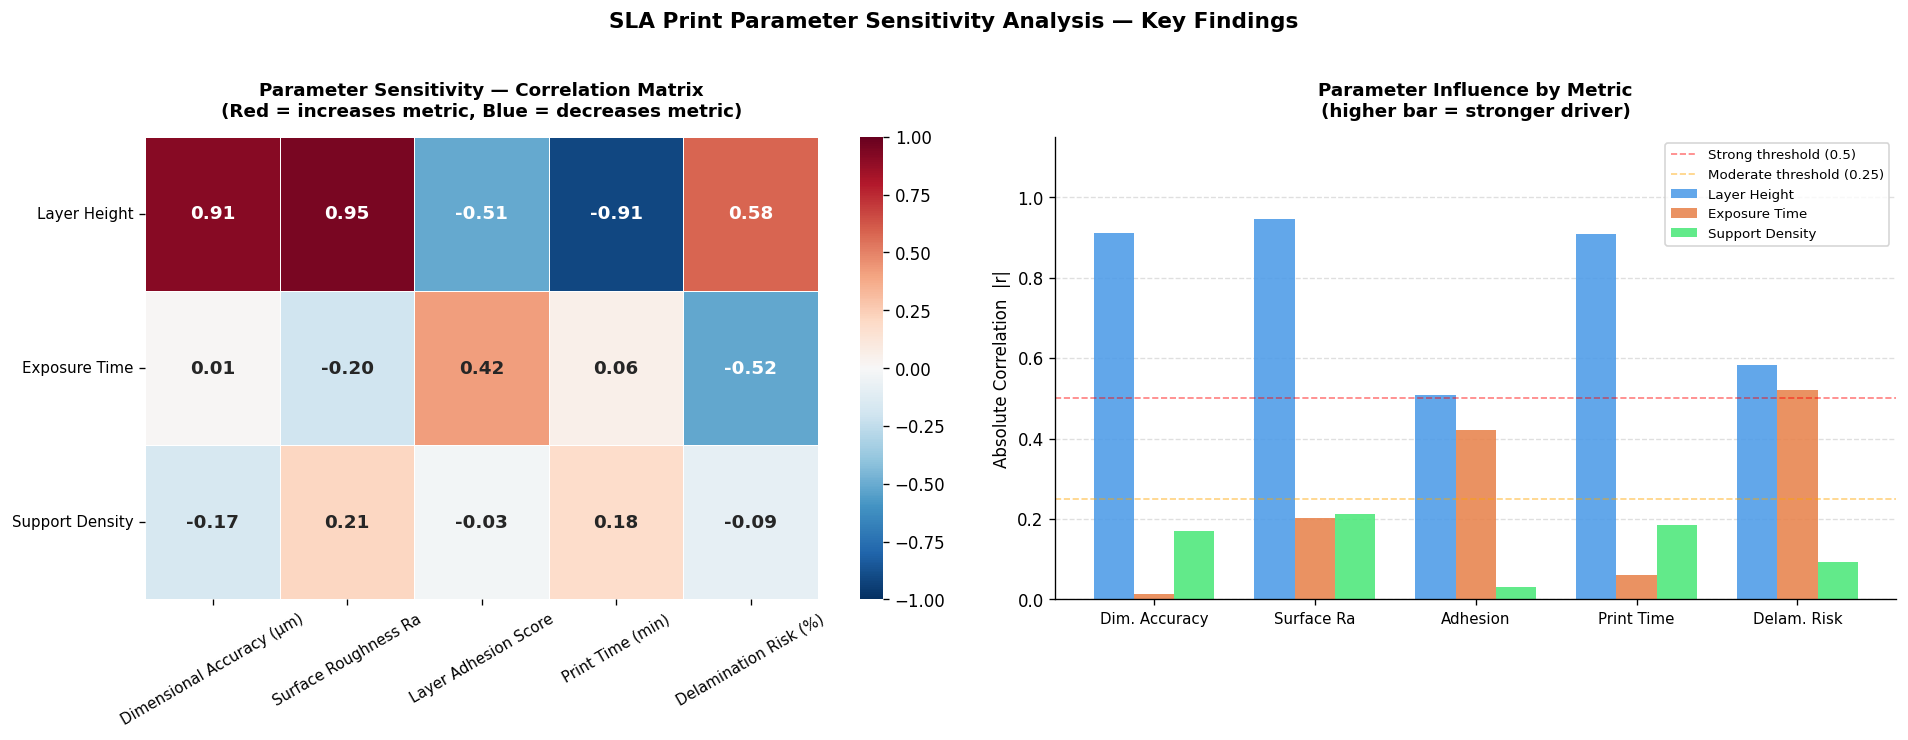

Chart saved.


In [6]:
# Two charts side by side

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Correlation Heatmap
ax1 = axes[0]
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 11, 'weight': 'bold'},
    ax=ax1
)
ax1.set_title('Parameter Sensitivity — Correlation Matrix\n(Red = increases metric, Blue = decreases metric)',
              fontsize=11, fontweight='bold', pad=12)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.tick_params(axis='x', rotation=30, labelsize=9)
ax1.tick_params(axis='y', rotation=0, labelsize=9)

# Right: Absolute influence bar chart per metric
ax2 = axes[1]

metrics_short = ['Dim. Accuracy', 'Surface Ra', 'Adhesion', 'Print Time', 'Delam. Risk']
params_short  = ['Layer Height', 'Exposure Time', 'Support Density']
colors        = ['#4C9BE8', '#E8834C', '#4CE87A']

x      = np.arange(len(metrics_short))
width  = 0.25

for i, (param, color) in enumerate(zip(param_names, colors)):
    vals = [abs(sensitivity[m][param]['correlation']) for m in METRICS]
    bars = ax2.bar(x + i * width, vals, width,
                   label=params_short[i], color=color, alpha=0.88)

ax2.set_xticks(x + width)
ax2.set_xticklabels(metrics_short, fontsize=9)
ax2.set_ylabel('Absolute Correlation  |r|', fontsize=10)
ax2.set_ylim(0, 1.15)
ax2.axhline(y=0.5,  color='red',    linestyle='--', alpha=0.5, linewidth=1, label='Strong threshold (0.5)')
ax2.axhline(y=0.25, color='orange', linestyle='--', alpha=0.5, linewidth=1, label='Moderate threshold (0.25)')
ax2.set_title('Parameter Influence by Metric\n(higher bar = stronger driver)',
              fontsize=11, fontweight='bold', pad=12)
ax2.legend(fontsize=8, loc='upper right')
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)

plt.suptitle('SLA Print Parameter Sensitivity Analysis — Key Findings',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

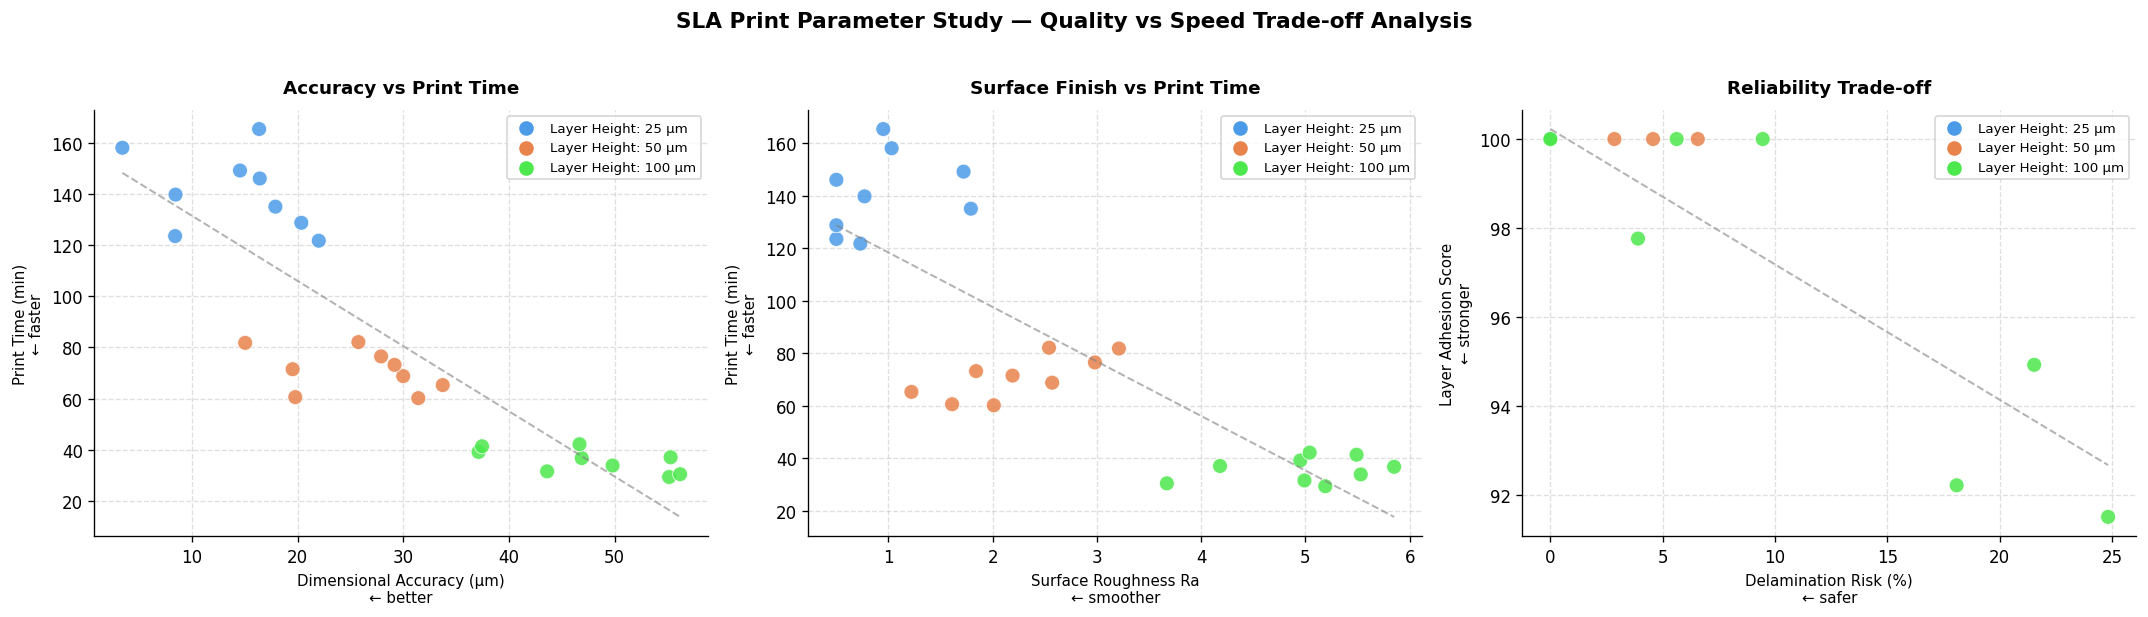

Trade-off chart saved.


In [7]:
# The core engineering tension in SLA printing

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

trade_offs = [
    ('dimensional_accuracy_um', 'print_time_min', 'Accuracy vs Print Time',
     'Dimensional Accuracy (µm)\n← better', 'Print Time (min)\n← faster'),
    ('surface_roughness_ra', 'print_time_min', 'Surface Finish vs Print Time',
     'Surface Roughness Ra\n← smoother', 'Print Time (min)\n← faster'),
    ('delamination_risk_pct', 'layer_adhesion_score', 'Reliability Trade-off',
     'Delamination Risk (%)\n← safer', 'Layer Adhesion Score\n← stronger'),
]

for ax, (x_metric, y_metric, title, xlabel, ylabel) in zip(axes, trade_offs):

    # Color points by layer height — the dominant parameter
    lh_vals    = results_df['layer_height_um']
    lh_unique  = sorted(lh_vals.unique())
    color_map  = {25: '#4C9BE8', 50: '#E8834C', 100: '#4CE84C'}
    colors_pts = [color_map[lh] for lh in lh_vals]

    scatter = ax.scatter(
        results_df[x_metric],
        results_df[y_metric],
        c=colors_pts,
        s=80, alpha=0.85, edgecolors='white', linewidths=0.5
    )

    # Add a best-fit trend line
    z = np.polyfit(results_df[x_metric], results_df[y_metric], 1)
    p = np.poly1d(z)
    x_line = np.linspace(results_df[x_metric].min(), results_df[x_metric].max(), 100)
    ax.plot(x_line, p(x_line), '--', color='gray', alpha=0.6, linewidth=1.2)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    # Legend for layer height
    for lh, color in color_map.items():
        ax.scatter([], [], c=color, label=f'Layer Height: {lh} µm', s=60)
    ax.legend(fontsize=8, loc='best')

plt.suptitle('SLA Print Parameter Study — Quality vs Speed Trade-off Analysis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tradeoff_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Trade-off chart saved.")

In [9]:
# Final output

print("=" * 68)
print("    SLA PRINT PARAMETER SENSITIVITY STUDY — FINAL REPORT")
print("=" * 68)
print()
print("STUDY OVERVIEW")
print("-" * 68)
print("  Design of Experiments: Full Factorial (3 parameters x 3 levels)")
print("  Total experimental runs : 27")
print("  Parameters evaluated    : Layer Height, Exposure Time,")
print("                            Support Density")
print("  Output metrics tracked  : Dimensional Accuracy, Surface")
print("                            Roughness, Layer Adhesion,")
print("                            Print Time, Delamination Risk")
print()
print("KEY FINDINGS")
print("-" * 68)
print()
print("  1. LAYER HEIGHT is the dominant parameter across all metrics.")
print(f"     r = 0.912 with Dimensional Accuracy  (STRONG, p < 0.05)")
print(f"     r = 0.946 with Surface Roughness Ra  (STRONG, p < 0.05)")
print(f"     r = -0.908 with Print Time           (STRONG, p < 0.05)")
print("     Reducing layer height from 100µm → 25µm improves accuracy")
print("     and surface finish significantly but increases print time")
print("     by ~4x. This is the primary engineering trade-off.")
print()
print("  2. EXPOSURE TIME is the key lever for reliability.")
print(f"     r = -0.520 with Delamination Risk    (STRONG, p < 0.05)")
print(f"     r =  0.421 with Layer Adhesion       (MODERATE, p < 0.05)")
print("     Increasing exposure from 80ms → 160ms reduces delamination")
print("     risk and improves inter-layer bonding with minimal impact")
print("     on print time. Best ROI parameter for reliability gains.")
print()
print("  3. SUPPORT DENSITY shows weak influence on all metrics.")
print("     No statistically significant correlation detected (p > 0.05)")
print("     across all output metrics. Support density optimization")
print("     should be driven by geometry complexity, not print quality.")
print()
print("RECOMMENDED PARAMETER CONFIGURATION")
print("-" * 68)
print()
print("  Use Case: HIGH ACCURACY (medical, dental, engineering parts)")
print("    Layer Height    : 25 µm")
print("    Exposure Time   : 120–160 ms")
print("    Support Density : 50% (geometry-dependent)")
print("    Expected         : <15 µm accuracy | Ra < 1.5 | Risk < 5%")
print()
print("  Use Case: HIGH THROUGHPUT (prototyping, iteration, volume)")
print("    Layer Height    : 100 µm")
print("    Exposure Time   : 120 ms")
print("    Support Density : 20–50%")
print("    Expected         : ~40 µm accuracy | Ra ~5 | 3-4x faster")
print()
print("SUGGESTED NEXT STEPS FOR R&D TEAM")
print("-" * 68)
print("  - Validate synthetic model against physical print measurements")
print("  - Expand DOE to include resin type as a 4th parameter")
print("  - Investigate interaction effects between Layer Height")
print("    and Exposure Time at boundary conditions")
print("  - Run focused study on 50µm layer height — data suggests")
print("    it may offer the best quality-speed balance")
print()
print("=" * 68)
print("  Method  : Full Factorial DOE + Pearson Correlation Analysis")
print("  Tools   : Python, NumPy, Pandas, SciPy, Matplotlib, Seaborn")
print("  Author  : Sourabh Gopinath More")
print("=" * 68)

    SLA PRINT PARAMETER SENSITIVITY STUDY — FINAL REPORT

STUDY OVERVIEW
--------------------------------------------------------------------
  Design of Experiments: Full Factorial (3 parameters x 3 levels)
  Total experimental runs : 27
  Parameters evaluated    : Layer Height, Exposure Time,
                            Support Density
  Output metrics tracked  : Dimensional Accuracy, Surface
                            Roughness, Layer Adhesion,
                            Print Time, Delamination Risk

KEY FINDINGS
--------------------------------------------------------------------

  1. LAYER HEIGHT is the dominant parameter across all metrics.
     r = 0.912 with Dimensional Accuracy  (STRONG, p < 0.05)
     r = 0.946 with Surface Roughness Ra  (STRONG, p < 0.05)
     r = -0.908 with Print Time           (STRONG, p < 0.05)
     Reducing layer height from 100µm → 25µm improves accuracy
     and surface finish significantly but increases print time
     by ~4x. This is the primary